# Evaluación Parcial N°3 - Deep Learning

## Notebook 1: Clasificación de sentimientos con LSTM

En este notebook se desarrolla un modelo recurrente basado en LSTM para clasificar reseñas de películas como positivas o negativas.

La tarea corresponde a un problema de Procesamiento de Lenguaje Natural, donde el texto de cada reseña será transformado en secuencias numéricas mediante tokenización y padding. Posteriormente, estas secuencias serán utilizadas para entrenar una red neuronal recurrente.

El objetivo es evaluar el desempeño del modelo utilizando métricas de clasificación como accuracy, precision, recall y F1-score.

# Librerias


In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SpatialDropout1D, LSTM, Dense, Dropout

# Carga del dataset

In [25]:
df = pd.read_csv("IMDB_Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


# Exploración inicial del dataset

In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     50000 non-null  str  
 1   sentiment  50000 non-null  str  
dtypes: str(2)
memory usage: 781.4 KB


In [27]:
df.shape

(50000, 2)

In [28]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [29]:
df['sentiment'].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

El dataset contiene 50.000 reseñas y dos columnas principales: `review`, que contiene el texto de la reseña, y `sentiment`, que contiene la etiqueta asociada. No existen valores nulos y las clases están balanceadas, con 25.000 reseñas positivas y 25.000 reseñas negativas.

# Visualización de la distribución de clases

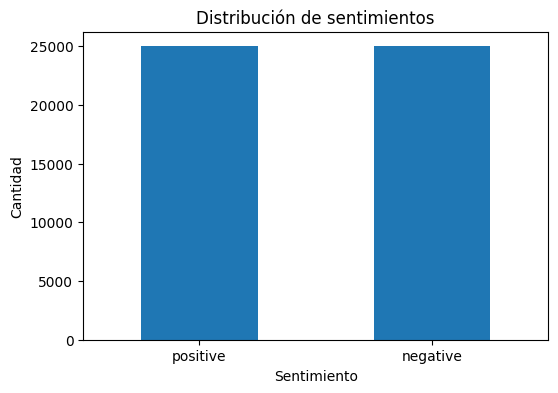

In [30]:
df['sentiment'].value_counts().plot(
    kind='bar',
    figsize=(6,4)
)

plt.title('Distribución de sentimientos')
plt.xlabel('Sentimiento')
plt.ylabel('Cantidad')
plt.xticks(rotation=0)
plt.show()

La distribución de clases es equilibrada.

## 5. Análisis de longitud de las reseñas

Se analiza la longitud de las reseñas para decidir posteriormente un tamaño máximo de secuencia durante el proceso de padding.

In [31]:
df['review'].str.len().describe()

count    50000.000000
mean      1309.431020
std        989.728014
min         32.000000
25%        699.000000
50%        970.000000
75%       1590.250000
max      13704.000000
Name: review, dtype: float64

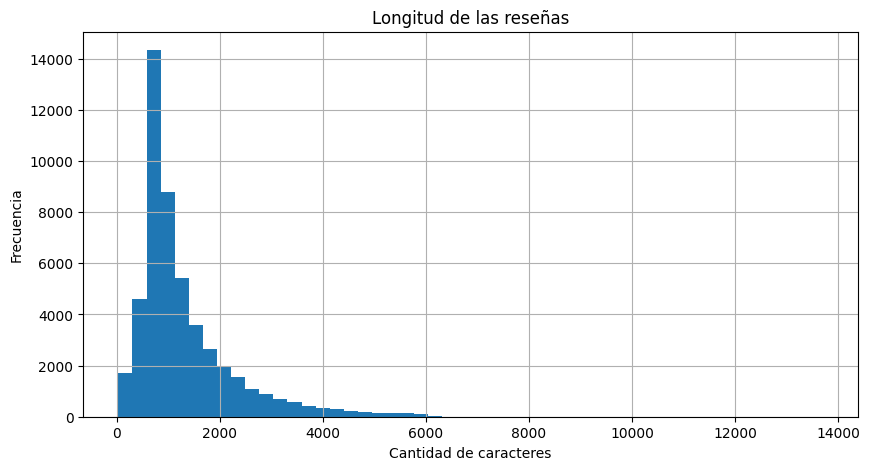

In [32]:
plt.figure(figsize=(10,5))

df['review'].str.len().hist(bins=50)

plt.title('Longitud de las reseñas')
plt.xlabel('Cantidad de caracteres')
plt.ylabel('Frecuencia')

plt.show()

Las reseñas presentan longitudes variables. La mayoría se concentra en textos de longitud media, aunque existen algunas reseñas mucho más extensas. Por esta razón, se aplicará padding para que todas las secuencias tengan el mismo largo antes de ingresar al modelo LSTM.

## Preprocesamiento del texto

Antes de entrenar la red neuronal transformaremos los datos a un formato numérico.

- negative → 0
- positive → 1

Posteriormente, las reseñas serán tokenizadas y transformadas en secuencias de números para que puedan ser procesadas por la red LSTM.

In [33]:
df['sentiment'] = df['sentiment'].map({
    'negative': 0,
    'positive': 1
})

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


In [34]:
# Separación de variables

X = df['review']
y = df['sentiment']

In [35]:
# Division del conjunto de datos

# Se utiliza la opción `stratify` para mantener la misma proporción de clases en ambos conjuntos.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [36]:
print('Entrenamiento:', X_train.shape)
print('Prueba:', X_test.shape)

Entrenamiento: (40000,)
Prueba: (10000,)


# Tokenizacion del texto


Se utilizarán:

- Máximo de palabras del vocabulario: 10.000.
- Longitud máxima de secuencia: 200 palabras.

In [37]:
MAX_WORDS = 10000
MAX_LEN = 200

In [38]:
tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    lower=True
)

tokenizer.fit_on_texts(X_train)

Una vez construido el vocabulario, las reseñas se transforman en secuencias de números enteros.

In [39]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [40]:
print(X_train_seq[0][:30])

[10, 1054, 11, 119, 1505, 457, 31, 1608, 142, 8, 4300, 38, 10, 13, 30, 3, 8743, 1671, 5, 63, 105, 158, 671, 868, 867, 97, 1, 1671, 13, 2836]


Las secuencias obtenidas poseen longitudes distintas, por lo que se aplicará padding para que todas tengan el mismo tamaño.

In [41]:
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN
)

In [42]:
print(X_train_pad.shape)
print(X_test_pad.shape)

(40000, 200)
(10000, 200)


Después del padding, todas las reseñas tienen la misma longitud de 200 palabras, lo que permite ingresarlas correctamente al modelo LSTM.

## Construcción del modelo LSTM

Se implementará una arquitectura basada en:

- Embedding.
- SpatialDropout1D.
- LSTM.
- Dropout.
- Capa de salida con activación Sigmoid.

Esta arquitectura es adecuada para problemas de clasificación binaria y permite capturar dependencias temporales presentes en el texto.

In [43]:
model = Sequential()

model.add(
    Embedding(
        input_dim=MAX_WORDS,
        output_dim=128,
        input_length=MAX_LEN
    )
)

model.add(
    SpatialDropout1D(0.4)
)

model.add(
    LSTM(128)
)

model.add(
    Dropout(0.4)
)

model.add(
    Dense(
        1,
        activation='sigmoid'
    )
)

c:\Users\benja\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [44]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

El modelo contiene una capa Embedding de 128 dimensiones y una capa LSTM con 128 neuronas.

La función de activación Sigmoid es adecuada para problemas de clasificación binaria, ya que entrega una probabilidad asociada a cada una de las dos clases.

## 11. Compilación del modelo

El modelo será entrenado utilizando:

- Función de pérdida: Binary Crossentropy.
- Optimizador: Adam.
- Métrica de entrenamiento: Accuracy.

La función Binary Crossentropy es la más utilizada en problemas de clasificación binaria.

In [45]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

## 12. Entrenamiento del modelo

El entrenamiento se realizará utilizando:

- Epochs: 5
- Batch Size: 64
- Validation Split: 20%

Durante el entrenamiento se almacenará el historial para posteriormente visualizar las curvas de aprendizaje.

In [46]:
history = model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.20
)

Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 158s 308ms/step - accuracy: 0.7933 - loss: 0.4434 - val_accuracy: 0.8639 - val_loss: 0.3417
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 149s 299ms/step - accuracy: 0.8929 - loss: 0.2735 - val_accuracy: 0.8662 - val_loss: 0.3330
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 143s 285ms/step - accuracy: 0.9140 - loss: 0.2260 - val_accuracy: 0.8731 - val_loss: 0.3134
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 141s 281ms/step - accuracy: 0.9326 - loss: 0.1840 - val_accuracy: 0.8834 - val_loss: 0.3121
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 132s 264ms/step - accuracy: 0.9398 - loss: 0.1624 - val_accuracy: 0.8855 - val_loss: 0.3234


In [47]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (64, 200, 128)         │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (64, 200, 128)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (64, 128)              │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (64, 128)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (64, 1)                │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,235,141 (16.16 MB)

 Trainable params: 1,411,713 (5.39 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,823,428 (10.77 MB)

El modelo posee aproximadamente 4,2 millones de parámetros, de los cuales 1,4 millones son entrenables. La mayor cantidad de parámetros se encuentra en la capa Embedding, ya que cada palabra del vocabulario es representada mediante un vector de 128 dimensiones.

La capa LSTM contiene 128 neuronas y es la encargada de aprender las dependencias presentes en las secuencias de texto, permitiendo realizar la clasificación de sentimientos.

# Predicciones del modelo


In [48]:
y_pred_prob = model.predict(X_test_pad)

313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 53ms/step


# Conversión de probabilidades a clases  (0 o 1)

In [49]:
y_pred = (
    y_pred_prob > 0.5
).astype(int)

# Cálculo de métricas

In [50]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

# Tabla de Resultados

In [51]:
resultados = pd.DataFrame({
    'Métrica': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1-score'
    ],
    'Valor': [
        accuracy,
        precision,
        recall,
        f1
    ]
})

resultados

,Métrica,Valor
0,Accuracy,0.881700
1,Precision,0.891327
2,Recall,0.869400
3,F1-score,0.880227


# Reporte completo

In [52]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.87      0.89      0.88      5000
           1       0.89      0.87      0.88      5000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



# Matriz de Confusión

In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred
)

cm

array([[4470,  530],
       [ 653, 4347]])

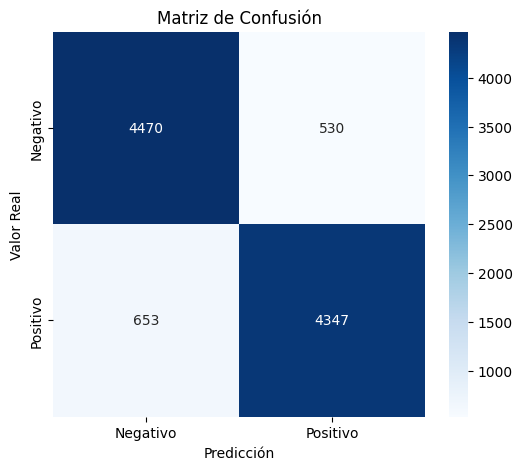

In [56]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negativo','Positivo'],
    yticklabels=['Negativo','Positivo']
)

plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión')

plt.show()

# Accuracy

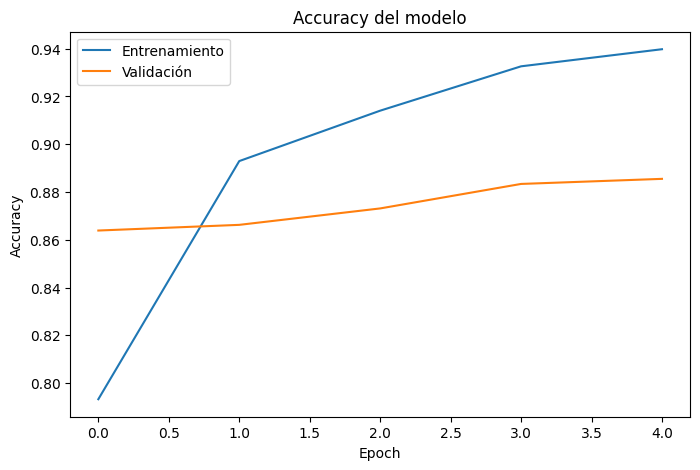

In [57]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    label='Entrenamiento'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validación'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy del modelo')
plt.legend()

plt.show()

# Gráfico de Loss


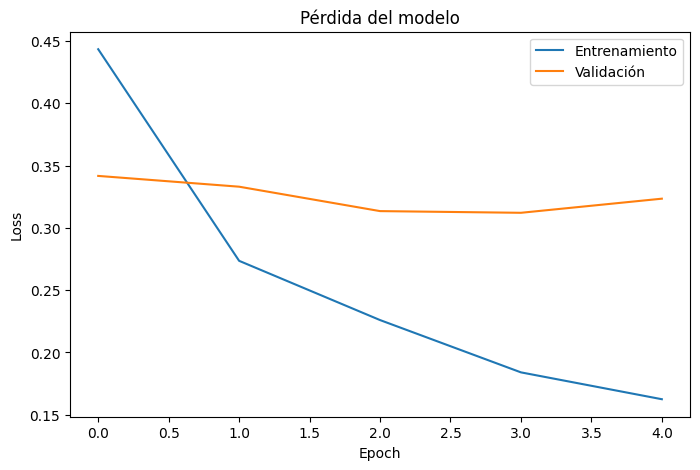

In [58]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    label='Entrenamiento'
)

plt.plot(
    history.history['val_loss'],
    label='Validación'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Pérdida del modelo')
plt.legend()

plt.show()

## Interpretación de las métricas

El modelo obtuvo un accuracy de 88,17%, indicando que aproximadamente 88 de cada 100 reseñas fueron clasificadas correctamente.

La precisión obtenida fue de 89,13%, lo que significa que cuando el modelo predice una reseña positiva, en la mayoría de los casos la predicción es correcta.

El recall alcanzó un valor de 86,94%, demostrando que el modelo logra identificar una gran parte de las reseñas positivas presentes en el conjunto de prueba.

Finalmente, el F1-score de 88,02% indica un buen equilibrio entre precisión y recall, evidenciando un desempeño general satisfactorio del modelo.

# Comparación de configuraciones

Se entrena una segunda configuración del modelo LSTM para comparar el impacto de los hiperparámetros en el desempeño.

In [59]:
model_a = Sequential()

model_a.add(
    Embedding(
        input_dim=MAX_WORDS,
        output_dim=128,
        input_length=MAX_LEN
    )
)

model_a.add(
    SpatialDropout1D(0.3)
)

model_a.add(
    LSTM(64)
)

model_a.add(
    Dropout(0.3)
)

model_a.add(
    Dense(
        1,
        activation='sigmoid'
    )
)

model_a.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

c:\Users\benja\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [60]:
history_a = model_a.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.20
)

Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 71s 132ms/step - accuracy: 0.8093 - loss: 0.4167 - val_accuracy: 0.8819 - val_loss: 0.2947
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 55s 110ms/step - accuracy: 0.8987 - loss: 0.2605 - val_accuracy: 0.8885 - val_loss: 0.2761
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 65s 130ms/step - accuracy: 0.9256 - loss: 0.1999 - val_accuracy: 0.8737 - val_loss: 0.3007
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 67s 134ms/step - accuracy: 0.9415 - loss: 0.1594 - val_accuracy: 0.8865 - val_loss: 0.3193
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 66s 131ms/step - accuracy: 0.9529 - loss: 0.1330 - val_accuracy: 0.8440 - val_loss: 0.4005


In [61]:
y_pred_prob_a = model_a.predict(X_test_pad)

y_pred_a = (
    y_pred_prob_a > 0.5
).astype(int)

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step


In [62]:
accuracy_a = accuracy_score(y_test, y_pred_a)
precision_a = precision_score(y_test, y_pred_a)
recall_a = recall_score(y_test, y_pred_a)
f1_a = f1_score(y_test, y_pred_a)

In [63]:
comparacion = pd.DataFrame({
    'Modelo': [
        'Configuración A',
        'Configuración B'
    ],
    'LSTM': [
        64,
        128
    ],
    'Dropout': [
        0.3,
        0.4
    ],
    'Epochs': [
        5,
        5
    ],
    'Batch Size': [
        64,
        64
    ],
    'Learning Rate': [
        'Adam default',
        'Adam default'
    ],
    'Accuracy': [
        accuracy_a,
        accuracy
    ],
    'Precision': [
        precision_a,
        precision
    ],
    'Recall': [
        recall_a,
        recall
    ],
    'F1-score': [
        f1_a,
        f1
    ]
})

comparacion

,Modelo,LSTM,Dropout,Epochs,Batch Size,Learning Rate,Accuracy,Precision,Recall,F1-score
0,Configuración A,64,0.3,5,64,Adam default,0.8460,0.922363,0.7556,0.830695
1,Configuración B,128,0.4,5,64,Adam default,0.8817,0.891327,0.8694,0.880227


# Selección del modelo final

Se compararon dos configuraciones de hiperparámetros modificando la cantidad de neuronas LSTM y el porcentaje de Dropout.

La Configuración B obtuvo el mejor desempeño general, alcanzando el mayor Accuracy y F1-score, además de un mejor equilibrio entre Precision y Recall.

Por esta razón, se seleccionó como el modelo final para la tarea de clasificación de sentimientos.

# Conclusiones

Se implementó un modelo LSTM para clasificación de sentimientos utilizando reseñas de películas del dataset IMDB.

El modelo final obtuvo un buen desempeño, alcanzando resultados cercanos al 88% en accuracy y F1-score. Además, se compararon dos configuraciones de hiperparámetros modificando la cantidad de neuronas LSTM y el Dropout.

La configuración final permitió obtener un equilibrio adecuado entre precisión, recall y F1-score, demostrando que las redes LSTM son útiles para procesar secuencias de texto y resolver problemas de clasificación binaria en NLP.